# Đồ Án: Phân tích và Ước lượng Độ mặn ĐBSCL (Spatiotemporal Regression)
Nhóm thực hiện: Đỗ Như Minh Hiếu, Trần Tiến Đức, Lê Xuân Hoàng

*Dự án sử dụng vị trí trạm, tháng quan trắc và mực nước thượng nguồn Tân Châu để ước lượng độ mặn.*


### 1. Thu thập dữ liệu
Sử dụng dữ liệu quan trắc độ mặn ĐBSCL và dữ liệu mực nước Tân Châu theo ngày giai đoạn 2016-2026.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sal = pd.read_csv('../data/raw/CSDL_DSS1_20240109_1.csv', low_memory=False)
df_sal = df_sal.iloc[1:].copy()
df_sal['Date'] = pd.to_datetime(df_sal['Date'], format='%d/%m/%Y', errors='coerce')
df_sal['Salinity'] = pd.to_numeric(df_sal['Salinity'], errors='coerce')
df_sal['longitude'] = pd.to_numeric(df_sal['longitude'], errors='coerce')
df_sal['latitude'] = pd.to_numeric(df_sal['latitude'], errors='coerce')

df_wl = pd.read_json('../data/raw/WaterLevel/TanChau_WaterLevel_2016_2026_daily.json')
df_wl['ObservationDate'] = pd.to_datetime(df_wl['ObservationDate'], errors='coerce').dt.normalize()
df_wl = df_wl.rename(columns={'WaterLevel': 'TanChau_WaterLevel'})

print(f'Salinity shape: {df_sal.shape}')
print(f'Tan Chau Water Level shape: {df_wl.shape}')


Salinity shape: (2696, 33)
Tan Chau Water Level shape: (3646, 2)


### 2. Làm sạch và ghép dữ liệu (Đa biến Thủy văn)
Thay vì sử dụng các công thức tính toán Khoảng cách và Vận tốc dòng chảy phức tạp, chúng ta sẽ áp dụng chiến lược học máy thông minh:
Chế tạo 3 biến thủy văn đại diện cho nhiều khoảng thời gian chảy khác nhau từ Tân Châu xuống biển:
1. `TanChau_WL_Lag7`: Mực nước Tân Châu 7 ngày trước.
2. `TanChau_WL_Lag14`: Mực nước Tân Châu 14 ngày trước.
3. `TanChau_WL_MA7`: Trung bình trượt (Moving Average) mực nước trong 7 ngày qua.

Khi đưa cả 3 biến này vào Random Forest cùng với Tọa độ (Lat, Lon), thuật toán sẽ **tự động học được khoảng thời gian trễ (Travel Time) tối ưu cho từng trạm cụ thể**, giúp kết quả dự báo cực kỳ sát với quy luật vật lý!


In [2]:
# Loại bỏ các dòng thiếu thông tin quan trọng
df_sal = df_sal.dropna(subset=['Date', 'Salinity', 'longitude', 'latitude']).sort_values('Date')
df_wl = df_wl.dropna(subset=['ObservationDate', 'TanChau_WaterLevel']).sort_values('ObservationDate')
df_wl = df_wl.drop_duplicates(subset='ObservationDate')

# Kỹ thuật Đa biến Thủy văn (Lags & Moving Average)
df_wl['TanChau_WL_Lag7'] = df_wl['TanChau_WaterLevel'].shift(7)
df_wl['TanChau_WL_Lag14'] = df_wl['TanChau_WaterLevel'].shift(14)
df_wl['TanChau_WL_MA7'] = df_wl['TanChau_WaterLevel'].shift(1).rolling(window=7).mean()

# Bỏ đi các dòng trống (NaN) sinh ra do quá trình trễ (shift)
df_wl = df_wl.dropna()

# Ghép dữ liệu chuẩn theo từng ngày
df_clean = df_sal.merge(
    df_wl,
    left_on='Date',
    right_on='ObservationDate',
    how='inner'
)

print(f'Dữ liệu sau khi làm sạch và ghép: {df_clean.shape}')
print(f'Tỷ lệ giữ lại: {len(df_clean) / len(df_sal):.1%}')
display(df_clean[['Kyhieu', 'Date', 'longitude', 'latitude', 'Salinity', 'TanChau_WL_Lag7', 'TanChau_WL_Lag14', 'TanChau_WL_MA7']].head())


Dữ liệu sau khi làm sạch và ghép: (2649, 38)
Tỷ lệ giữ lại: 98.3%


,Kyhieu,Date,longitude,latitude,Salinity,TanChau_WL_Lag7,TanChau_WL_Lag14,TanChau_WL_MA7
0,TGLX7,2016-03-17,105.09,10.02,0.1,0.67,0.52,0.307143
1,TGLX8,2016-03-17,104.93,10.19,9.1,0.67,0.52,0.307143
2,TGLX5,2016-03-17,104.87,10.51,0.0,0.67,0.52,0.307143
3,TGLX4,2016-03-17,105.06,10.44,0.0,0.67,0.52,0.307143
4,TGLX10,2016-03-17,104.52,10.37,1.1,0.67,0.52,0.307143


### 3. Khai phá và phân tích dữ liệu (EDA)

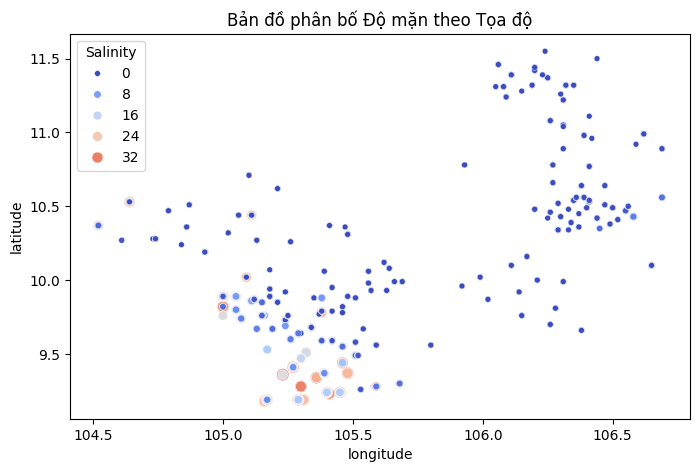

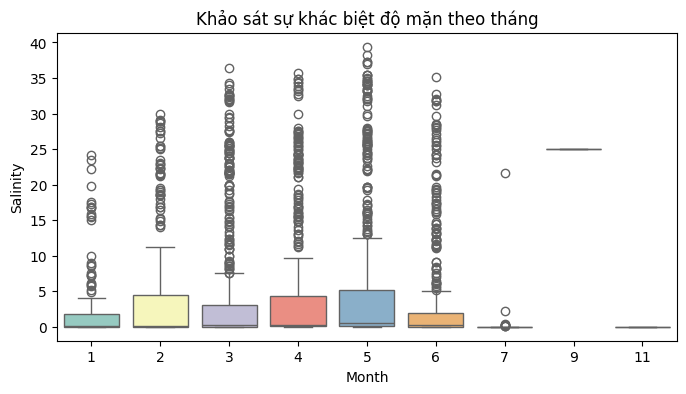

In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='Salinity', size='Salinity', palette='coolwarm')
plt.title('Bản đồ phân bố Độ mặn theo Tọa độ')
plt.show()

df_clean['Month'] = df_clean['Date'].dt.month
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x='Month', y='Salinity', hue='Month', palette='Set3', legend=False)
plt.title('Khảo sát sự khác biệt độ mặn theo tháng')
plt.show()

### 4. Lập mô hình học máy
Sử dụng Random Forest và XGBoost cho bài toán hồi quy không-thời gian. Mực nước Tân Châu là biến proxy đại diện cho điều kiện thượng nguồn, không phải mực nước tại từng trạm độ mặn.


In [4]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Khởi tạo mô hình cơ bản
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

### 5. Xây dựng Feature và Chia tập dữ liệu
Các feature gồm vị trí trạm (`longitude`, `latitude`), tháng quan trắc (`Month`) và bộ 3 biến Thủy văn (`TanChau_WL_Lag7`, `TanChau_WL_Lag14`, `TanChau_WL_MA7`). Huấn luyện trên dữ liệu trước 2022 và kiểm thử trên dữ liệu năm 2022.


In [5]:
features = ['longitude', 'latitude', 'Month', 'TanChau_WL_Lag7', 'TanChau_WL_Lag14', 'TanChau_WL_MA7']
target = 'Salinity'

df_clean['Year'] = df_clean['Date'].dt.year
train_df = df_clean[df_clean['Year'] < 2022]
test_df = df_clean[df_clean['Year'] == 2022]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f'Kích thước tập Train: {len(X_train)}')
print(f'Kích thước tập Test: {len(X_test)}')


Kích thước tập Train: 2310
Kích thước tập Test: 339


### 6. Đánh giá và So sánh mô hình (Sử dụng Log Transformation)
Dùng `log1p` để giảm ảnh hưởng của phân phối target lệch và đánh giá lại kết quả trên thang độ mặn gốc bằng hàm `np.expm1`.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_log(model, name):
    # Huấn luyện trên không gian Logarit
    model.fit(X_train, np.log1p(y_train))
    # Dự báo và bung log
    y_pred_log = model.predict(X_test)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    return {'Model': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae}, y_pred

# 1. Baseline: Trung bình của trạm lịch sử
station_means = train_df.groupby('Kyhieu')['Salinity'].mean().to_dict()
pred_baseline = test_df['Kyhieu'].map(station_means).fillna(train_df['Salinity'].mean())
res_baseline = {'Model': 'Station Mean (Baseline)', 'R2 Score': r2_score(y_test, pred_baseline), 
                'RMSE': np.sqrt(mean_squared_error(y_test, pred_baseline)), 'MAE': mean_absolute_error(y_test, pred_baseline)}

# 2. Đánh giá Model
res_rf, pred_rf = evaluate_log(model_rf, 'Random Forest (Log1p)')
res_xgb, pred_xgb = evaluate_log(model_xgb, 'XGBoost (Log1p)')

results_df = pd.DataFrame([res_baseline, res_rf, res_xgb])
display(results_df)

,Model,R2 Score,RMSE,MAE
0,Station Mean (Baseline),-0.060169,7.003389,4.561523
1,Random Forest (Log1p),0.418514,5.186690,2.785018
2,XGBoost (Log1p),0.364717,5.421312,2.993464


### 7. Truyền đạt kết quả và Triển khai thực tiễn

**7.1. Phân phối sai số (Residual Analysis)**
Kiểm tra xem các sai số (Thực tế - Ước lượng) có tập trung quanh mức 0 hay không.

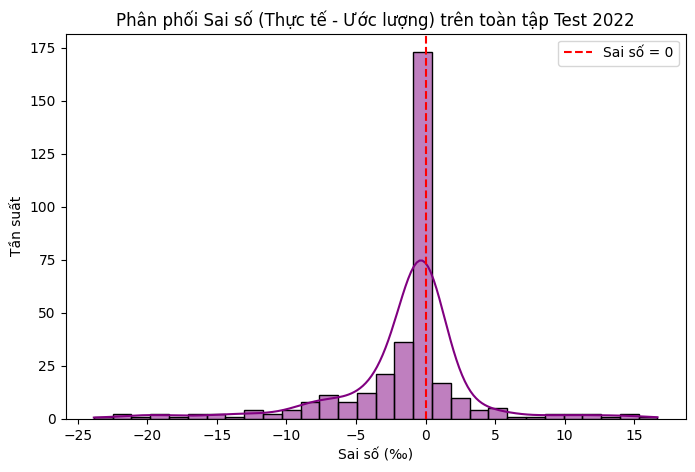

In [7]:
residuals = y_test - pred_rf
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Phân phối Sai số (Thực tế - Ước lượng) trên toàn tập Test 2022')
plt.xlabel('Sai số (‰)')
plt.ylabel('Tần suất')
plt.axvline(x=0, color='red', linestyle='--', label='Sai số = 0')
plt.legend()
plt.show()

**7.2. Đối chiếu chi tiết tại Trạm QL1 (Năm 2022)**
Trích xuất trạm QL1 để so sánh thực tế và ước lượng. Biểu đồ dùng dạng phân tán (Scatter).

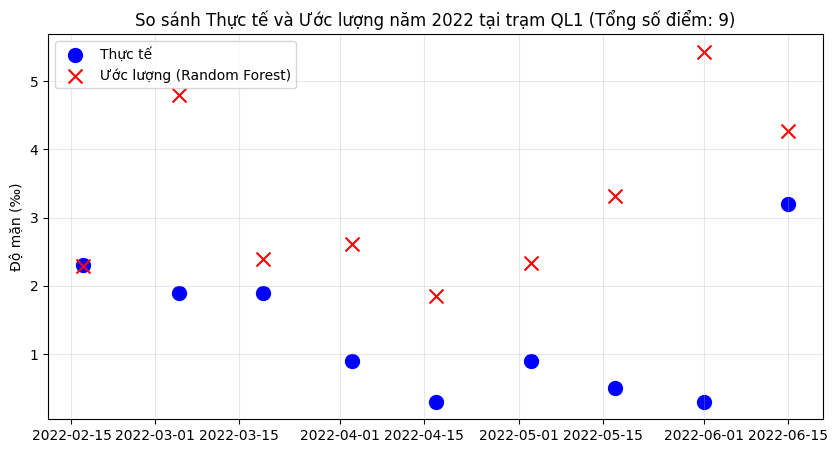

In [8]:
tram_test = 'QL1'
df_tram = test_df[test_df['Kyhieu'] == tram_test].copy()
if not df_tram.empty:
    df_tram['UocLuong'] = np.clip(np.expm1(model_rf.predict(df_tram[features])), 0, None)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(df_tram['Date'], df_tram['Salinity'], c='blue', s=100, label='Thực tế')
    plt.scatter(df_tram['Date'], df_tram['UocLuong'], c='red', marker='x', s=100, label='Ước lượng (Random Forest)')
    plt.title(f'So sánh Thực tế và Ước lượng năm 2022 tại trạm {tram_test} (Tổng số điểm: {len(df_tram)})')
    plt.ylabel('Độ mặn (‰)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()